In [ ]:
#girl picture filtering


import numpy as np
from PIL import Image
import os

def generate_4x4_stimulus(image_path, output_hex="girl_4x4.hex"):
    N = 512
    try:
        # 1. Load the image using the provided variable
        if not os.path.exists(image_path):
            print(f"Error: {image_path} not found. Please upload it to your environment.")
            return

        # Opening image and converting to Grayscale
        img = Image.open("salt_pepper_girl_512x512.gif").convert('L')

        # 2. Resize to 512x512
        img = img.resize((N, N), Image.Resampling.LANCZOS)
        img_array = np.array(img)

        # 3. Apply Proper Padding for a 4x4 window
        # To keep the output 512x512, we need padding.
        # For an even kernel like 4x4, we typically pad 1 pixel on top/left
        # and 2 pixels on bottom/right to center the operation.
        padded_img = np.pad(img_array, pad_width=((1, 2), (1, 2)), mode='edge')

        # 4. Extract windows and write to file
        with open(output_hex, "w") as f:
            for r in range(N):
                # Progress tracker
                if r % 100 == 0:
                    print(f"Generating: {int((r/N)*100)}% complete...")

                for c in range(N):
                    # Extract 4x4 block (16 pixels)
                    # Window order: [r,c], [r,c+1]...[r+3,c+3]
                    window = padded_img[r:r+4, c:c+4].flatten()

                    # Format as space-separated hex values (in1 in2 ... in16)
                    hex_line = " ".join([f"{int(p):02x}" for p in window])
                    f.write(hex_line + "\n")

        print("-" * 30)
        print(f"Success! Generated {N*N} windows in '{output_hex}'")
        print(f"Ready for 4x4 Shear Sort Verilog main module.")
        print("-" * 30)

    except Exception as e:
        print(f"Error: {e}")

# Call the function with your specific file
generate_4x4_stimulus("salt_pepper_girl_512x512.gif")

Generating: 0% complete...
Generating: 19% complete...
Generating: 39% complete...
Generating: 58% complete...
Generating: 78% complete...
Generating: 97% complete...
------------------------------
Success! Generated 262144 windows in 'girl_4x4.hex'
Ready for 4x4 Shear Sort Verilog main module.
------------------------------


Reading Verilog output file...
Reading stimulus input file...


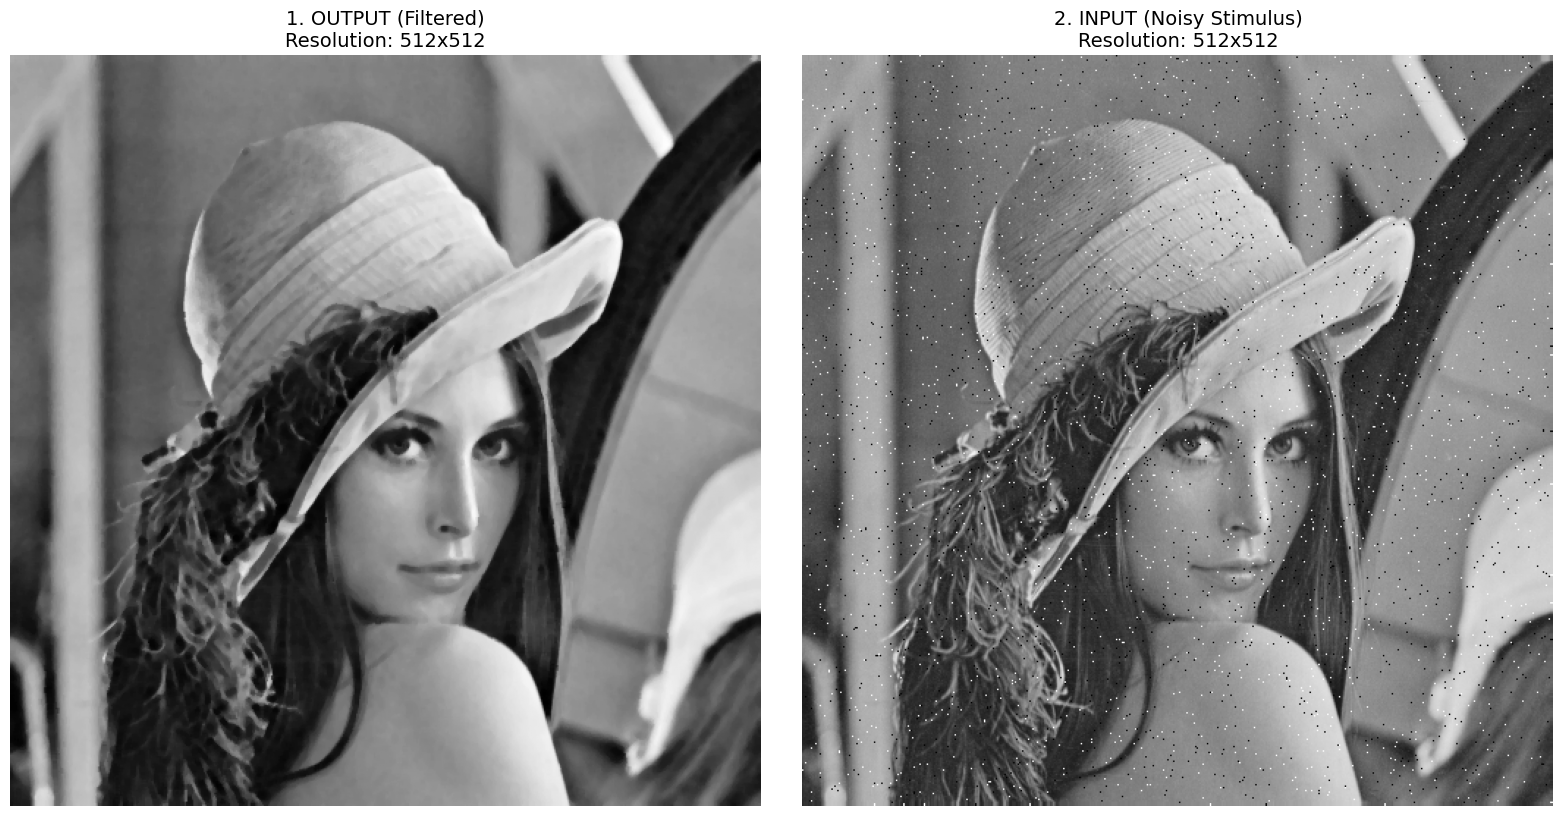

Comparison successful. Image saved as 'comparison_512.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compare_512_results(input_hex="girl_4x4.hex", output_hex="result_girl_512.hex", N=512):
    try:
        print("Reading Verilog output file...")
        # 1. Load the Filtered Output (Result from Verilog)
        with open(output_hex, 'r') as f:
            # result_512.hex contains one median value per line
            output_data = [int(line.strip(), 16) for line in f if line.strip()]

        if len(output_data) != N*N:
            print(f"Warning: Output file has {len(output_data)} pixels. Expected {N*N}.")
            # Adjust list size if simulation was incomplete to avoid reshape error
            output_data = output_data[:N*N] + [0]*(max(0, N*N - len(output_data)))

        output_img = np.array(output_data).reshape((N, N))

        print("Reading stimulus input file...")
        # 2. Reconstruct the Noisy Input (From Stimulus)
        # We extract one representative pixel (index 10) from each 4x4 window
        input_data = []
        with open(input_hex, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 16:
                    # Index 10 corresponds to the approximate center of the 4x4 window
                    input_data.append(int(parts[10], 16))

        input_img = np.array(input_data).reshape((N, N))

        # 3. Create the Side-by-Side Plot
        plt.figure(figsize=(16, 8))

        # Left: Filtered Output (As you requested: First is Output)
        plt.subplot(1, 2, 1)
        plt.imshow(output_img, cmap='gray')
        plt.title(f"1. OUTPUT (Filtered)\nResolution: {N}x{N}", fontsize=14)
        plt.axis('off')

        # Right: Noisy Input
        plt.subplot(1, 2, 2)
        plt.imshow(input_img, cmap='gray')
        plt.title(f"2. INPUT (Noisy Stimulus)\nResolution: {N}x{N}", fontsize=14)
        plt.axis('off')

        plt.tight_layout()
        plt.savefig("comparison_512.png", dpi=300)
        plt.show()
        print("Comparison successful. Image saved as 'comparison_512.png'")

    except FileNotFoundError as e:
        print(f"Error: {e}. Ensure both .hex files are in the same directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Run the comparison script
compare_512_results()

In [ ]:
#cameraman picture filtering

import numpy as np
import math

def calculate_hardware_metrics(input_hex="girl_4x4.hex", output_hex="result_girl_512.hex", N=512):
    try:
        # 1. Load Filtered Output
        with open(output_hex, 'r') as f:
            out_data = [int(line.strip(), 16) for line in f if line.strip()]
        out_arr = np.array(out_data).reshape((N, N))

        # 2. Load Noisy Input (using center anchor index 10)
        in_data = []
        with open(input_hex, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 16:
                    in_data.append(int(parts[10], 16))
        in_arr = np.array(in_data).reshape((N, N))

        # 3. Calculate MSE (Mean Squared Error)
        # Higher MSE here means the filter changed the image a lot (removed a lot of noise)
        mse = np.mean((in_arr.astype(float) - out_arr.astype(float)) ** 2)

        # 4. Calculate PSNR (Peak Signal-to-Noise Ratio)
        if mse == 0:
            psnr = 100 # Perfect match
        else:
            max_pixel = 255.0
            psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

        # 5. Calculate "Noise Reduction Intensity"
        # (Standard deviation of the difference)
        noise_removed_std = np.std(in_arr.astype(float) - out_arr.astype(float))

        print("-" * 30)
        print(f"HARDWARE FILTER METRICS ({N}x{N})")
        print("-" * 30)
        print(f"Mean Squared Error (MSE):  {mse:.2f}")
        print(f"Peak Signal-to-Noise (PSNR): {psnr:.2f} dB")
        print(f"Noise Removal Intensity:     {noise_removed_std:.2f} levels")
        print("-" * 30)

        return mse, psnr

    except Exception as e:
        print(f"Calculation Error: {e}")

# Execute the calculation
calculate_hardware_metrics()

------------------------------
HARDWARE FILTER METRICS (512x512)
------------------------------
Mean Squared Error (MSE):  350.20
Peak Signal-to-Noise (PSNR): 22.69 dB
Noise Removal Intensity:     18.02 levels
------------------------------


(np.float64(350.1971626281738), 22.687677378524054)

Reading Verilog output file...
Reading stimulus input file...


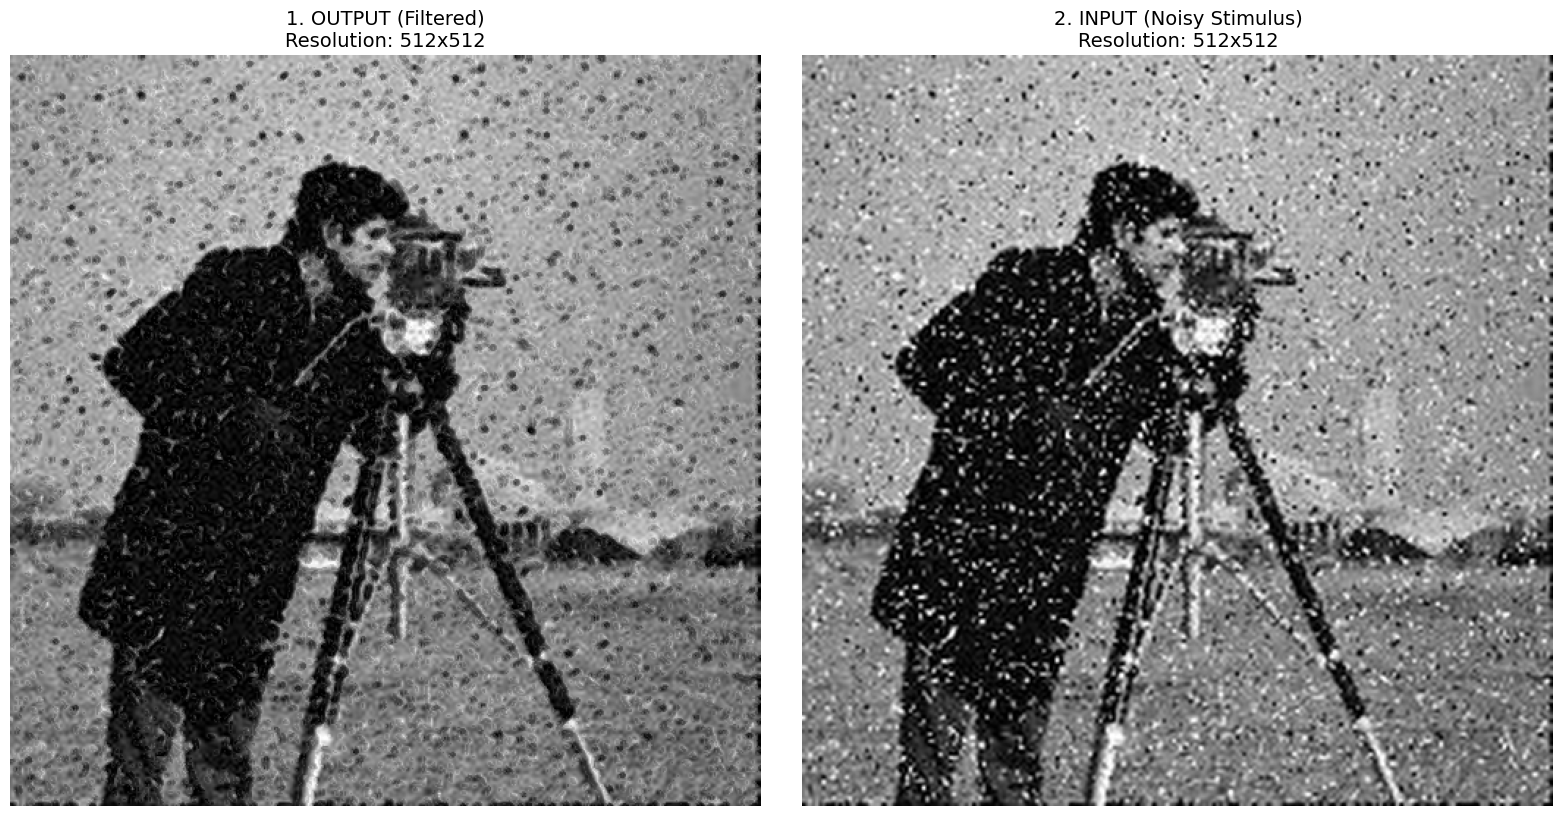

Comparison successful. Image saved as 'comparison_512.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compare_512_results(input_hex="camera_man_512.hex", output_hex="result_adaptive_512.hex", N=512):
    try:
        print("Reading Verilog output file...")
        # 1. Load the Filtered Output (Result from Verilog)
        with open(output_hex, 'r') as f:
            # result_512.hex contains one median value per line
            output_data = [int(line.strip(), 16) for line in f if line.strip()]

        if len(output_data) != N*N:
            print(f"Warning: Output file has {len(output_data)} pixels. Expected {N*N}.")
            # Adjust list size if simulation was incomplete to avoid reshape error
            output_data = output_data[:N*N] + [0]*(max(0, N*N - len(output_data)))

        output_img = np.array(output_data).reshape((N, N))

        print("Reading stimulus input file...")
        # 2. Reconstruct the Noisy Input (From Stimulus)
        # We extract one representative pixel (index 10) from each 4x4 window
        input_data = []
        with open(input_hex, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 16:
                    # Index 10 corresponds to the approximate center of the 4x4 window
                    input_data.append(int(parts[10], 16))

        input_img = np.array(input_data).reshape((N, N))

        # 3. Create the Side-by-Side Plot
        plt.figure(figsize=(16, 8))

        # Left: Filtered Output (As you requested: First is Output)
        plt.subplot(1, 2, 1)
        plt.imshow(output_img, cmap='gray')
        plt.title(f"1. OUTPUT (Filtered)\nResolution: {N}x{N}", fontsize=14)
        plt.axis('off')

        # Right: Noisy Input
        plt.subplot(1, 2, 2)
        plt.imshow(input_img, cmap='gray')
        plt.title(f"2. INPUT (Noisy Stimulus)\nResolution: {N}x{N}", fontsize=14)
        plt.axis('off')

        plt.tight_layout()
        plt.savefig("comparison_512.png", dpi=300)
        plt.show()
        print("Comparison successful. Image saved as 'comparison_512.png'")

    except FileNotFoundError as e:
        print(f"Error: {e}. Ensure both .hex files are in the same directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Run the comparison script
compare_512_results()

In [ ]:
import numpy as np
import math

def calculate_hardware_metrics(input_hex="camera_man_512.hex", output_hex="result_adaptive_512.hex", N=512):
    try:
        # 1. Load Filtered Output
        with open(output_hex, 'r') as f:
            out_data = [int(line.strip(), 16) for line in f if line.strip()]
        out_arr = np.array(out_data).reshape((N, N))

        # 2. Load Noisy Input (using center anchor index 10)
        in_data = []
        with open(input_hex, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 16:
                    in_data.append(int(parts[10], 16))
        in_arr = np.array(in_data).reshape((N, N))

        # 3. Calculate MSE (Mean Squared Error)
        # Higher MSE here means the filter changed the image a lot (removed a lot of noise)
        mse = np.mean((in_arr.astype(float) - out_arr.astype(float)) ** 2)

        # 4. Calculate PSNR (Peak Signal-to-Noise Ratio)
        if mse == 0:
            psnr = 100 # Perfect match
        else:
            max_pixel = 255.0
            psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

        # 5. Calculate "Noise Reduction Intensity"
        # (Standard deviation of the difference)
        noise_removed_std = np.std(in_arr.astype(float) - out_arr.astype(float))

        print("-" * 30)
        print(f"HARDWARE FILTER METRICS ({N}x{N})")
        print("-" * 30)
        print(f"Mean Squared Error (MSE):  {mse:.2f}")
        print(f"Peak Signal-to-Noise (PSNR): {psnr:.2f} dB")
        print(f"Noise Removal Intensity:     {noise_removed_std:.2f} levels")
        print("-" * 30)

        return mse, psnr

    except Exception as e:
        print(f"Calculation Error: {e}")

# Execute the calculation
calculate_hardware_metrics()

------------------------------
HARDWARE FILTER METRICS (512x512)
------------------------------
Mean Squared Error (MSE):  666.04
Peak Signal-to-Noise (PSNR): 19.90 dB
Noise Removal Intensity:     24.30 levels
------------------------------


(np.float64(666.0403137207031), 19.895798441652104)